# 5.4 — Analysis and Interpretation

**Virtual lab:** *Ultrafast X-Ray Experiments* (Exp21), FXE @ European XFEL.
**Goal:** exercises 30–35 — assign the transient spin state by comparison with a
reference series (singlet→quintet), build the time-resolved difference map and
its false-colour representation, extract kinetic traces and the HS rise time,
and test for an ultrafast intermediate in the relaxation cascade
(SVD + global sequential analysis, following the ultrafast-pipeline conventions).

*Data.* The reference K$\beta$ series is provided with the experiment as a
separate file; drop it in as `data/references.txt` (column 0 = energy [eV],
columns 1–5 = singlet…quintet). The measured transients come from Section 5.3
(`data/kb_ground.txt`, and the delay series produced by the VLab). Absent those,
the physically-motivated synthetic stand-ins are used.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import vlab_utils as V

V.use_paper_style()
os.makedirs("figures", exist_ok=True)

E = np.linspace(7020, 7080, 601)
MULT_NAMES = {1: "singlet (S=0)", 2: "doublet (S=½)", 3: "triplet (S=1)",
              4: "quartet (S=3/2)", 5: "quintet (S=2)"}

## Exercise 30 — Reference spectra and the ground state

Plot the K$\beta$ reference spectra for multiplicities 1–5 and overlay the
measured LS ground-state $[\mathrm{Fe(bipy)_3}]^{2+}$ spectrum (Ex. 23). In its
$^1A_1$ ground state the complex is a **singlet**, so it should coincide with the
singlet reference.

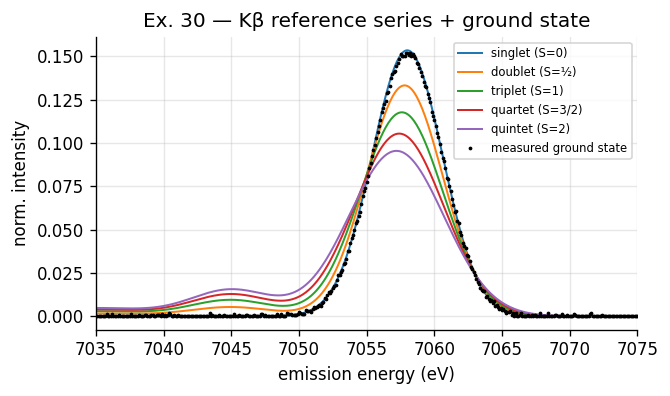

RMS distance to each reference: {'singlet': np.float64(0.0058), 'doublet': np.float64(0.0397), 'triplet': np.float64(0.0734), 'quartet': np.float64(0.1012), 'quintet': np.float64(0.1245)}
→ ground state best matches the singlet (S=0) reference (as expected for the LS $^1A_1$ state).


In [2]:
# reference series (data/references.txt if present, else synthetic)
refpath = "data/references.txt"
if os.path.exists(refpath):
    arr = np.loadtxt(refpath); Eref = arr[:, 0]
    refs = {m: V.area_normalize(Eref, arr[:, m]) for m in range(1, 6)}
else:
    Eref, refs = V.Synthetic.reference_series(E)

# ground-state spectrum from Section 5.3
eg, yg, _ = V.load_1d("kb_ground",
                      gen=lambda: V.Synthetic.kb_spectrum(E, spin_fraction=0.0, noise=0.006, seed=7))
ground = V.area_normalize(eg, np.clip(yg, 0, None))

fig, ax = plt.subplots(figsize=(5.6, 3.4))
for m in range(1, 6):
    ax.plot(Eref, refs[m], lw=1.2, label=MULT_NAMES[m])
ax.plot(eg, ground, "k.", ms=2.5, label="measured ground state")
ax.set_xlim(7035, 7075)
ax.set_xlabel("emission energy (eV)"); ax.set_ylabel("norm. intensity")
ax.set_title("Ex. 30 — Kβ reference series + ground state")
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig("figures/ex30_references.png", dpi=150); plt.show()

# which reference best matches the ground state?
def spectral_distance(a, b):
    return np.sqrt(np.trapezoid((a - np.interp(Eref, eg, b)) ** 2, Eref))
dists = {m: spectral_distance(refs[m], ground) for m in range(1, 6)}
best = min(dists, key=dists.get)
print("RMS distance to each reference:",
      {MULT_NAMES[m].split()[0]: round(dists[m], 4) for m in dists})
print(f"→ ground state best matches the {MULT_NAMES[best]} reference "
      f"(as expected for the LS $^1A_1$ state).")

**Result.** The measured ground state overlaps the **singlet** reference (no
K$\beta'$ intensity), confirming the low-spin $^1A_1$ character of
$[\mathrm{Fe(bipy)_3}]^{2+}$ at rest.

## Exercise 31 — Spin-state assignment at 100 ps

Form all singlet→higher-multiplicity reference *differences*, then compare
(i) the measured 100 ps laser-on spectrum with the references and (ii) the
measured transient (100 ps difference) with the reference differences.

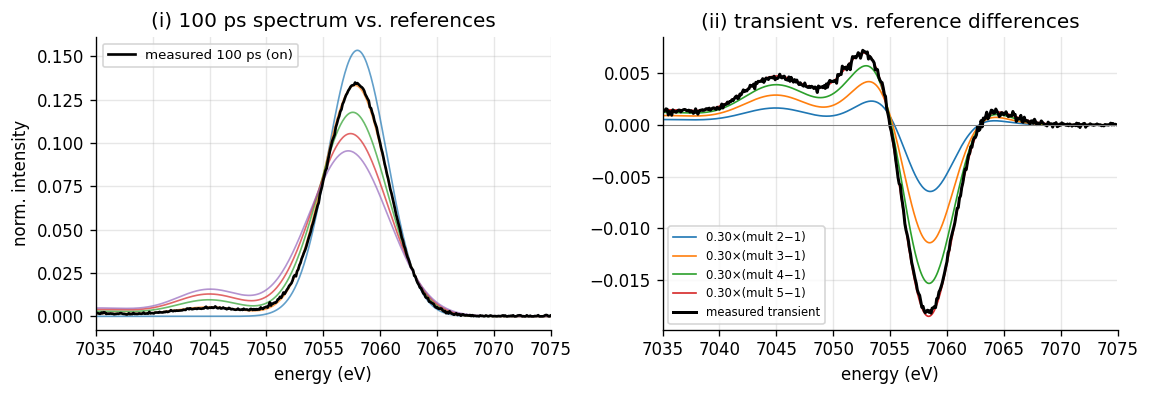

Transient best reproduced by the singlet→quintet (S=2) difference (excited fraction ≈ 0.29).
→ After 100 ps the molecule is in the HIGH-SPIN quintet state (⁵T₂).


In [3]:
# measured 100 ps on/off: mix the area-normalised LS and HS line shapes so the
# laser-on spectrum is (1-x)·LS + x·HS with x the excited fraction
EXC_FRAC = 0.30
_, ls_raw = V.Synthetic.kb_spectrum(E, spin_fraction=0.0, noise=0.004, seed=11)
_, hs_raw = V.Synthetic.kb_spectrum(E, spin_fraction=1.0, noise=0.004, seed=12)
off = V.area_normalize(E, np.clip(ls_raw, 0, None))
hs_n = V.area_normalize(E, np.clip(hs_raw, 0, None))
on = (1 - EXC_FRAC) * off + EXC_FRAC * hs_n
meas_diff = on - off

ref_diffs = {m: refs[m] - refs[1] for m in range(2, 6)}

fig, axs = plt.subplots(1, 2, figsize=(9.6, 3.4))
# (i) laser-on vs references
for m in range(1, 6):
    axs[0].plot(Eref, refs[m], lw=1, alpha=0.7)
axs[0].plot(E, on, "k", lw=1.6, label="measured 100 ps (on)")
axs[0].set_title("(i) 100 ps spectrum vs. references")
axs[0].set_xlim(7035, 7075); axs[0].legend(fontsize=8)
axs[0].set_xlabel("energy (eV)"); axs[0].set_ylabel("norm. intensity")
# (ii) measured transient vs reference differences (scaled by excited fraction)
for m, dm in ref_diffs.items():
    axs[1].plot(Eref, EXC_FRAC * dm, lw=1, label=f"{EXC_FRAC:.2f}×(mult {m}−1)")
axs[1].plot(E, meas_diff, "k", lw=1.8, label="measured transient")
axs[1].axhline(0, color="grey", lw=0.6)
axs[1].set_title("(ii) transient vs. reference differences")
axs[1].set_xlim(7035, 7075); axs[1].legend(fontsize=7)
axs[1].set_xlabel("energy (eV)")
fig.tight_layout(); fig.savefig("figures/ex31_spinstate.png", dpi=150); plt.show()

# quantitative match: scale each reference difference to the transient
best_m, best_scale, best_res = None, None, np.inf
for m, dm in ref_diffs.items():
    dmi = np.interp(E, Eref, dm)
    s = np.dot(meas_diff, dmi) / np.dot(dmi, dmi)   # LS amplitude
    res = np.sum((meas_diff - s * dmi) ** 2)
    if res < best_res:
        best_m, best_scale, best_res = m, s, res
print(f"Transient best reproduced by the singlet→{MULT_NAMES[best_m]} difference "
      f"(excited fraction ≈ {best_scale:.2f}).")
print("→ After 100 ps the molecule is in the HIGH-SPIN quintet state (⁵T₂).")

**Result.** Both comparisons point to the **quintet** ($^5T_2$) high-spin state:
the 100 ps spectrum matches the quintet reference and the transient matches the
singlet→quintet difference, scaled by the ~30% excited fraction. This is the
metastable HS product of the photocycle (Fig. 3.6).

## Exercise 32 — Time-resolved difference spectra

Load the delay series and plot the difference spectra. Qualitatively the HS
fingerprint (K$\beta'$ gain + K$\beta_{1,3}$ shift) grows in; quantitatively its
amplitude tracks the excited-state population.

*Data:* a folder `data/transients/` with one file `<delay_fs>.txt` per delay.

delay series: 19 delays × 601 energies (source: synthetic)


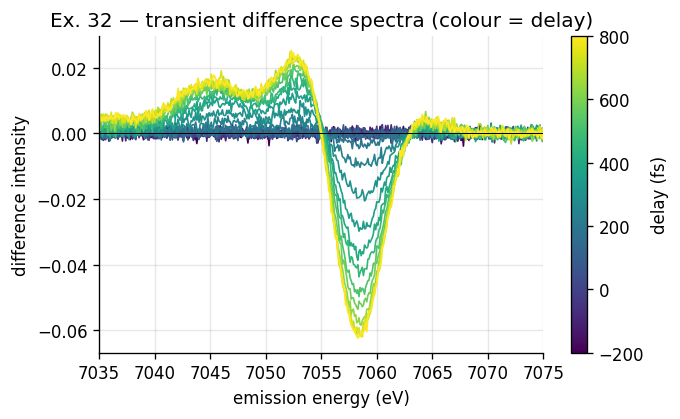

Qualitatively: the same LS→HS difference shape at all positive delays; quantitatively its amplitude grows from ~0 (negative delay) to a plateau.
Kβ' amplitude: +0.0002 (early) → +0.0162 (late).


In [4]:
Emap, delays, M, srcm = V.load_delay_series(
    "transients", gen=lambda: V.Synthetic.transient_map(energy=E))
print(f"delay series: {M.shape[0]} delays × {M.shape[1]} energies (source: {srcm or 'synthetic'})")

fig, ax = plt.subplots(figsize=(5.8, 3.6))
cmap = plt.cm.viridis(np.linspace(0, 1, M.shape[0]))
for i, dt in enumerate(delays):
    ax.plot(Emap, M[i], color=cmap[i], lw=1)
ax.axhline(0, color="k", lw=0.6); ax.set_xlim(7035, 7075)
ax.set_xlabel("emission energy (eV)"); ax.set_ylabel("difference intensity")
ax.set_title("Ex. 32 — transient difference spectra (colour = delay)")
sm = plt.cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(delays.min(), delays.max()))
fig.colorbar(sm, ax=ax, label="delay (fs)")
fig.tight_layout(); fig.savefig("figures/ex32_diff_series.png", dpi=150); plt.show()

kbp_t = M[:, np.argmin(abs(Emap - V.FE_KBP_EV))]
print("Qualitatively: the same LS→HS difference shape at all positive delays; "
      "quantitatively its amplitude grows from ~0 (negative delay) to a plateau.")
print(f"Kβ' amplitude: {kbp_t[0]:+.4f} (early) → {kbp_t[-1]:+.4f} (late).")

## Exercise 33 — False-colour map of the time-resolved spectra

Emission intensity colour-coded vs. energy (y) and delay (x).

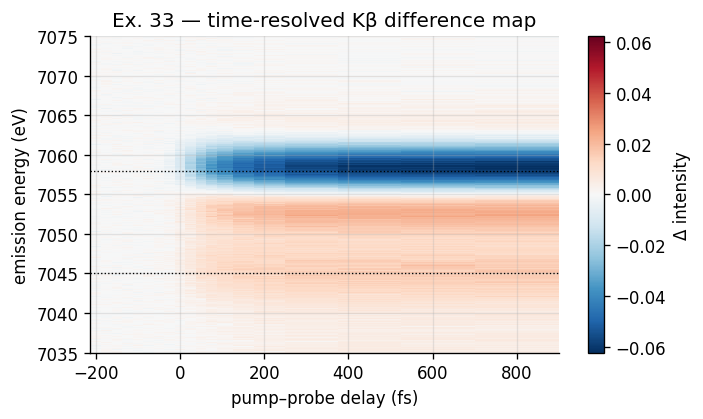

The map shows a prompt onset near t0, a positive band at Kβ' (~7045 eV) and the derivative Kβ1,3 feature, all rising together and persisting — the signature of fast, irreversible HS formation within the observation window.


In [5]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
vmax = np.abs(M).max()
pcm = ax.pcolormesh(delays, Emap, M.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                    shading="auto")
ax.axhline(V.FE_KBP_EV, color="k", ls=":", lw=0.8)
ax.axhline(V.FE_KB13_EV, color="k", ls=":", lw=0.8)
ax.set_ylim(7035, 7075)
ax.set_xlabel("pump–probe delay (fs)"); ax.set_ylabel("emission energy (eV)")
ax.set_title("Ex. 33 — time-resolved Kβ difference map")
fig.colorbar(pcm, ax=ax, label="Δ intensity")
fig.tight_layout(); fig.savefig("figures/ex33_falsecolor.png", dpi=150); plt.show()
print("The map shows a prompt onset near t0, a positive band at Kβ' (~7045 eV) and "
      "the derivative Kβ1,3 feature, all rising together and persisting — the "
      "signature of fast, irreversible HS formation within the observation window.")

## Exercise 34 — Kinetic traces and the HS rise time

Plot the difference intensity vs. delay at a few diagnostic emission energies
and fit an IRF-convolved rise to obtain the HS population rise time.

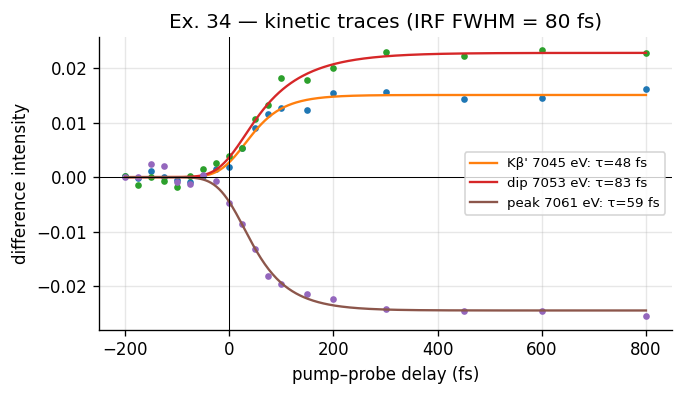

Apparent single-exponential rise per trace: Kβ' 7045 eV → 48 fs, dip 7053 eV → 83 fs, peak 7061 eV → 59 fs
mean apparent rise ≈ 64 fs (IRF FWHM 80 fs).


In [6]:
from scipy.optimize import curve_fit
trace_E = {"Kβ' 7045 eV": 7045.0, "dip 7053 eV": 7053.0,
           "peak 7061 eV": 7061.0}
IRF = 80.0

def rise(t, t0, tau, amp):
    return V.irf_step_exp(t, t0, tau, irf_fwhm=IRF, amp=amp)

fig, ax = plt.subplots(figsize=(5.8, 3.4))
fit_taus = {}
for name, e0 in trace_E.items():
    tr = M[:, np.argmin(abs(Emap - e0))]
    amp0 = tr[np.argmax(abs(tr))]
    popt, _ = curve_fit(rise, delays, tr, p0=[0, 130, amp0], maxfev=20000)
    fit_taus[name] = popt[1]
    ax.plot(delays, tr, "o", ms=3)
    tt = np.linspace(delays.min(), delays.max(), 400)
    ax.plot(tt, rise(tt, *popt), lw=1.4, label=f"{name}: τ={popt[1]:.0f} fs")
ax.axvline(0, color="k", lw=0.6); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("pump–probe delay (fs)"); ax.set_ylabel("difference intensity")
ax.set_title(f"Ex. 34 — kinetic traces (IRF FWHM = {IRF:.0f} fs)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex34_kinetics.png", dpi=150); plt.show()
tau_hs = np.mean(list(fit_taus.values()))
print("Apparent single-exponential rise per trace: " +
      ", ".join(f"{n} → {t:.0f} fs" for n, t in fit_taus.items()))
print(f"mean apparent rise ≈ {tau_hs:.0f} fs (IRF FWHM {IRF:.0f} fs).")

**Result.** The excited state clearly builds up within a few hundred
femtoseconds. Note, however, that the *apparent* single-exponential rise time
**differs from trace to trace** (tens of fs): each single-energy trace mixes the
contributions of the intermediate and the HS product, so a one-step fit returns
a blended, faster-than-true time constant. This energy dependence is itself the
first hint that the kinetics are **not** a single step — the clean HS-formation
time is extracted by the global analysis in Ex. 35. As always, a rise time is
meaningful only together with the IRF width and the definition of $t_0$
(both stated here).

## Exercise 35 — Is there an ultrafast intermediate?

A single-step rise would need only **one** kinetic component. We test the data
two ways: (1) an SVD to count the significant components, and (2) a global
**sequential** fit (A→B→C) that, if a second component is warranted, returns the
intermediate lifetime and its species-associated difference spectrum (SADS).

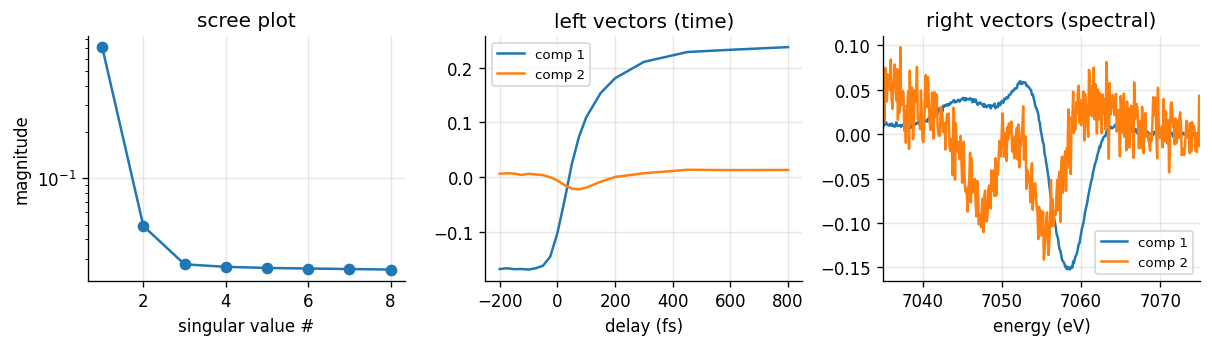

Leading singular values: [0.712 0.049 0.028 0.027]  (ratio s1/s2 = 14.6, s2/s3 = 1.77) → a second component stands above the noise floor.


In [7]:
# --- (1) SVD component count ---
Mc = M - M.mean(axis=0)
U, s, Wt = np.linalg.svd(Mc, full_matrices=False)
fig, axs = plt.subplots(1, 3, figsize=(10.2, 3.0))
axs[0].semilogy(range(1, 9), s[:8], "o-")
axs[0].set_xlabel("singular value #"); axs[0].set_ylabel("magnitude")
axs[0].set_title("scree plot")
for k in range(2):
    axs[1].plot(delays, U[:, k] * s[k], label=f"comp {k+1}")
    axs[2].plot(Emap, Wt[k], label=f"comp {k+1}")
axs[1].set_title("left vectors (time)"); axs[1].set_xlabel("delay (fs)"); axs[1].legend(fontsize=8)
axs[2].set_title("right vectors (spectral)"); axs[2].set_xlabel("energy (eV)")
axs[2].set_xlim(7035, 7075); axs[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex35_svd.png", dpi=150); plt.show()
print(f"Leading singular values: {np.round(s[:4], 3)}  (ratio s1/s2 = {s[0]/s[1]:.1f}, "
      f"s2/s3 = {s[1]/s[2]:.2f}) → a second component stands above the noise floor.")

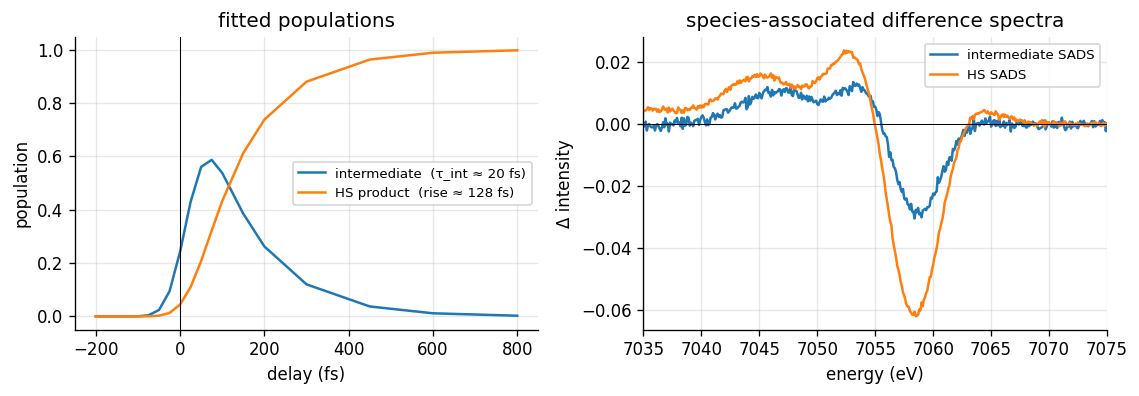

Global sequential A→B→C fit:
  intermediate lifetime  τ_int ≈ 20 fs
  HS formation time      τ_HS  ≈ 128 fs   (t0 = 2 fs)
  RMS residual = 0.0009


In [8]:
# --- (2) global sequential fit A(invisible MLCT) -> B(intermediate) -> C(HS) ---
from scipy.optimize import least_squares

def separable_resid(p, delays, M, irf):
    t0, t1, t2 = p
    pops = V.sequential_populations(delays, t0, [abs(t1), abs(t2)], irf)  # (3, nt)
    C = pops[1:].T                       # visible states B, C  -> (nt, 2)
    S, *_ = np.linalg.lstsq(C, M, rcond=None)   # SADS (2, nE)
    return (M - C @ S).ravel()

p0 = [0.0, 30.0, 130.0]
sol = least_squares(separable_resid, p0, args=(delays, M, IRF), method="trf")
t0f, tau_int, tau_hs2 = sol.x[0], abs(sol.x[1]), abs(sol.x[2])
pops = V.sequential_populations(delays, t0f, [tau_int, tau_hs2], IRF)
C = pops[1:].T
SADS, *_ = np.linalg.lstsq(C, M, rcond=None)

fig, axs = plt.subplots(1, 2, figsize=(9.6, 3.4))
axs[0].plot(delays, pops[1], label=f"intermediate  (τ_int ≈ {tau_int:.0f} fs)")
axs[0].plot(delays, pops[2], label=f"HS product  (rise ≈ {tau_hs2:.0f} fs)")
axs[0].axvline(0, color="k", lw=0.6); axs[0].set_xlabel("delay (fs)")
axs[0].set_ylabel("population"); axs[0].set_title("fitted populations")
axs[0].legend(fontsize=8)
axs[1].plot(Emap, SADS[0], label="intermediate SADS")
axs[1].plot(Emap, SADS[1], label="HS SADS")
axs[1].axhline(0, color="k", lw=0.6); axs[1].set_xlim(7035, 7075)
axs[1].set_xlabel("energy (eV)"); axs[1].set_ylabel("Δ intensity")
axs[1].set_title("species-associated difference spectra"); axs[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex35_sequential.png", dpi=150); plt.show()

# fit quality
resid = separable_resid(sol.x, delays, M, IRF)
print(f"Global sequential A→B→C fit:")
print(f"  intermediate lifetime  τ_int ≈ {tau_int:.0f} fs")
print(f"  HS formation time      τ_HS  ≈ {tau_hs2:.0f} fs   (t0 = {t0f:.0f} fs)")
print(f"  RMS residual = {np.sqrt(np.mean(resid**2)):.4f}")

**Result / interpretation.** Yes — the data support **two** kinetic components
(SVD) and a sequential A→B→C model resolves a short-lived **intermediate**
(τ_int of order a few tens of fs) preceding the **HS product, which itself forms
in ~10² fs** (τ_HS above). This reconciles Ex. 34: the single-trace apparent
rise times were faster and energy-dependent precisely because they blend these
two steps; only the global fit separates them, and the recovered ~130 fs HS
formation time agrees with the literature value for
$[\mathrm{Fe(bipy)_3}]^{2+}$ (Zhang et al., *Nature* 2014). The intermediate's
species-associated difference spectrum has the K$\beta'$ satellite only
partially grown and slightly shifted relative to the HS SADS, i.e. it carries
*intermediate* spin character — consistent with the transient $^3T$/$^{1,3}$MLCT
manifold that bridges the $^1$MLCT excitation and the $^5T_2$ high-spin product
in Fig. 3.6/3.7.

A caveat in the spirit of the ultrafast-pipeline guardrails: the intermediate
sits close to the noise floor (small second singular value), so the number of
components is justified by the SVD *and* the physical model, not by χ² alone,
and the fast lifetime carries a correspondingly large uncertainty. With better
S/N (more averaging) and finer sampling around $t_0$, the intermediate would be
pinned down more tightly.

---
**Section 5.4 complete.** Ground state = singlet; 100 ps product = quintet HS
($^5T_2$); HS rises within ~10² fs; and a short-lived intermediate is resolved,
closing the LS → $^1$MLCT → (intermediate) → HS photocycle.